In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("/content/polynomial_salary_dataset_100_rows.csv")

In [3]:
data.head()

,Level,Salary
0,1,1798
1,2,7192
2,3,16182
3,4,28768
4,5,44950


In [4]:
data.shape

(100, 2)

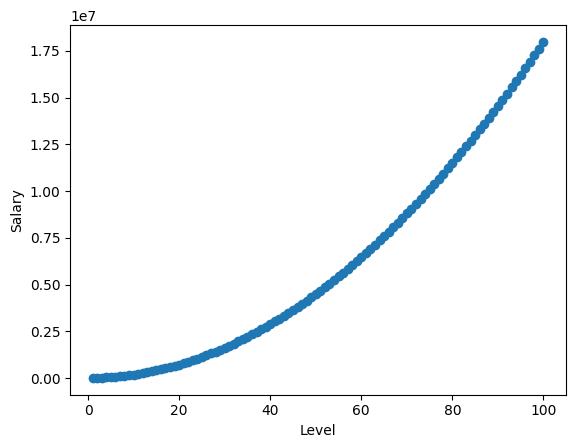

In [7]:
plt.scatter(data["Level"] , data["Salary"])
plt.xlabel("Level")
plt.ylabel("Salary")
plt.show()

In [6]:
data.corr()

,Level,Salary
Level,1.000000,0.968854
Salary,0.968854,1.000000


In [8]:
x=data[["Level"]]
y=data[["Salary"]]

In [9]:
from sklearn.preprocessing import PolynomialFeatures

In [11]:
pf = PolynomialFeatures(degree=2)
pf.fit(x)
x=pf.transform(x)

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
from sklearn.linear_model import LinearRegression

In [16]:
lr=LinearRegression()
lr.fit(x_train , y_train)

LinearRegression()

In [18]:
lr.score(x_test,y_test)*100

100.0

In [20]:
prd = lr.predict(x)

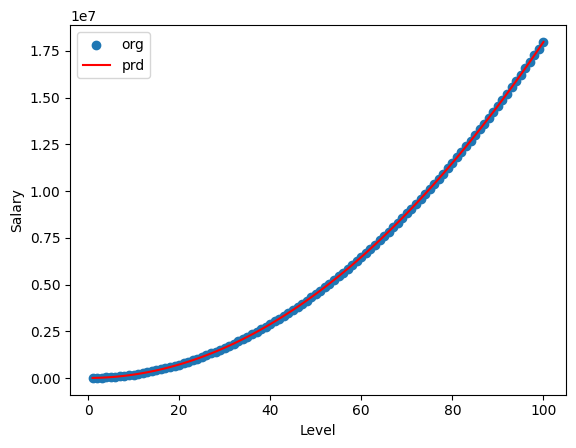

In [24]:
plt.scatter(data["Level"] , data["Salary"])
plt.plot(data["Level"],prd , c="r")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.legend(["org" , "prd"])
plt.show()

In [25]:
# y = m1x1 + m2x2^2 + c

In [26]:
lr.coef_

array([[ 0.00000000e+00, -7.20774551e-11,  1.79800000e+03]])

In [27]:
lr.intercept_

array([2.79396772e-09])

In [28]:
# y = -7.207*x1 + 1.798000*x2 + 2.7939

In [31]:
test = pf.transform([[5]])
test

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([[ 1.,  5., 25.]])

In [32]:
lr.predict(test)

array([[44950.]])